# Strategy Comparison Analysis

This notebook compares the performance of multiple strategies:
- Multi-Pattern Strategy (backtesting.py)
- SMC/ICT Strategy (custom engine)
- Buy & Hold benchmark

---

## Quick Configuration Guide

Modify the `CONFIG` dictionary in Section 1 to customize:
- Data source and date range
- Strategy parameters for each strategy
- Comparison metrics and visualization options

---

## 1. Configuration Section

**Modify parameters below to customize the comparison.**

In [1]:
# ============================================================
# CONFIGURATION - Modify these parameters to customize analysis
# ============================================================

CONFIG = {
    # ----------------------------------------------------------
    # Data Configuration
    # ----------------------------------------------------------
    'data': {
        'file': 'SPY_daily.csv',
        'directory': 'data/raw',
        'start_date': '2015-01-01',          # Start date for comparison
        'end_date': None,            # End date for comparison
        'columns': ['Open', 'High', 'Low', 'Close', 'Volume'],
    },
    
    # ----------------------------------------------------------
    # Multi-Pattern Strategy Configuration
    # ----------------------------------------------------------
    'multi_pattern': {
        'initial_equity': 100000,
        'commission': 0.001,
        'min_confidence': 0.55,
        'risk_per_trade': 0.02,
    },
    
    # ----------------------------------------------------------
    # SMC Strategy Configuration
    # ----------------------------------------------------------
    'smc': {
        'initial_equity': 100000,
        'commission_pct': 0.001,
        'slippage_pct': 0.0005,
        'risk_per_trade': 0.01,
    },
    
    # ----------------------------------------------------------
    # Benchmark Configuration
    # ----------------------------------------------------------
    'benchmark': {
        'initial_equity': 100000,
    },
    
    # ----------------------------------------------------------
    # Output Configuration
    # ----------------------------------------------------------
    'output': {
        'directory': 'reports',
        'save_plots': True,
        'show_plots': True,
        'dpi': 150,
    },
}

---

## 2. Setup and Imports

In [2]:
import sys
import warnings
from pathlib import Path
warnings.filterwarnings('ignore')

# Setup project root FIRST (before any src imports)
candidates = [
    Path('..').resolve(),
    Path('.').resolve(),
]
project_root = None
for root in candidates:
    if (root / 'src').exists():
        if str(root) not in sys.path:
            sys.path.insert(0, str(root))
        project_root = root
        break
if project_root is None:
    project_root = Path('.').resolve()
    if str(project_root) not in sys.path:
        sys.path.insert(0, str(project_root))

# Import notebook helpers
from src.utils.notebook_helpers import (
    load_price_data,
    print_data_summary,
    get_output_path,
    calculate_performance_metrics,
    print_metrics_comparison,
)

# Standard imports
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt

# Import backtesting.py integration
from src.strategies.backtest_py import BacktestPyRunner, MultiPatternStrategySimple

# Import custom engine
from src.backtest import BacktestEngine, BacktestConfig
from src.strategies import SMCReversalStrategy, SMCConfig

# Import visualization
from src.visualization import ReportGenerator

print("✅ Imports successful!")
print(f"Project root: {project_root}")

Loading BokehJS ...

✅ Imports successful!
Project root: C:\Dev\projects\investment_trying


---

## 3. Load Data

In [3]:
# Load data using helper function
df = load_price_data(CONFIG, project_root)

# Display data summary
print_data_summary(df, title="SPY Daily Data for Comparison")

📊 SPY Daily Data for Comparison
Date Range: 2015-01-02 to 2024-12-31
Total Trading Days: 2,516
Years of Data: 10.0

Columns: ['Open', 'High', 'Low', 'Close', 'Volume']

Data shape: (2516, 5)

First 5 rows:
                  Open        High         Low       Close     Volume
Date                                                                 
2015-01-02  171.378508  171.793709  169.551612  170.589615  121465900
2015-01-05  169.543303  169.709381  167.201575  167.508820  169632600
2015-01-06  167.816066  168.339223  165.133869  165.931061  209151400
2015-01-07  167.259737  168.339263  166.811325  167.998795  125346700
2015-01-08  169.410444  171.195817  169.393845  170.979904  147217800

📈 Price Statistics:
          Open     High      Low    Close
count  2516.00  2516.00  2516.00  2516.00
mean    310.27   311.95   308.44   310.31
std     114.48   115.04   113.85   114.49
min     154.54   156.03   152.88   154.98
25%     212.24   212.82   211.43   212.17
50%     273.24   273.96   272.2

---

## 4. Run Multi-Pattern Strategy

In [4]:
# Run Multi-Pattern Strategy
print("🚀 Running Multi-Pattern Strategy...")

mp_config = CONFIG['multi_pattern']

mp_runner = BacktestPyRunner(
    data=df,
    cash=mp_config['initial_equity'],
    commission=mp_config['commission']
)

mp_results = mp_runner.run(
    strategy_class=MultiPatternStrategySimple,
    min_confidence=mp_config['min_confidence'],
    risk_per_trade=mp_config['risk_per_trade']
)

# Get equity curve and trades
mp_equity = mp_runner.get_equity_curve()['Equity']
mp_trades = mp_runner.get_trades()

print(f"\n✅ Multi-Pattern Strategy complete!")
print(f"  Total trades: {len(mp_trades)}")
stats = mp_results.get('stats', mp_results)
if 'Return [%]' in stats:
    print(f"  Total return: {stats['Return [%]']:.2f}%")
else:
    print("  No trades generated - no return data")

🚀 Running Multi-Pattern Strategy...
Running backtest on 2516 bars...


Backtest.run:   0%|          | 0/2515 [00:00<?, ?bar/s]


BACKTEST SUMMARY
Start Date: 2015-01-02 00:00:00
End Date: 2024-12-31 00:00:00
Duration: 3651 days 00:00:00

Initial Capital: $100,000.00
Final Equity: $100,000.00
Final Return: 0.00%

Total Trades: 0
Win Rate: nan%
Best Trade: nan%
Worst Trade: nan%
Avg Trade: nan%

Max Drawdown: -0.00%
Sharpe Ratio: nan
Sortino Ratio: nan
Calmar Ratio: nan


✅ Multi-Pattern Strategy complete!
  Total trades: 0
  Total return: 0.00%


---

## 5. Calculate Buy & Hold Benchmark

In [5]:
# Calculate Buy & Hold returns
initial_capital = CONFIG['benchmark']['initial_equity']
shares = initial_capital / df['Close'].iloc[0]
bh_equity = df['Close'] * shares

bh_return = (bh_equity.iloc[-1] / initial_capital - 1) * 100
print(f"✅ Buy & Hold benchmark calculated")
print(f"  Total return: {bh_return:.2f}%")

✅ Buy & Hold benchmark calculated
  Total return: 239.57%


---

## 6. Compare Equity Curves

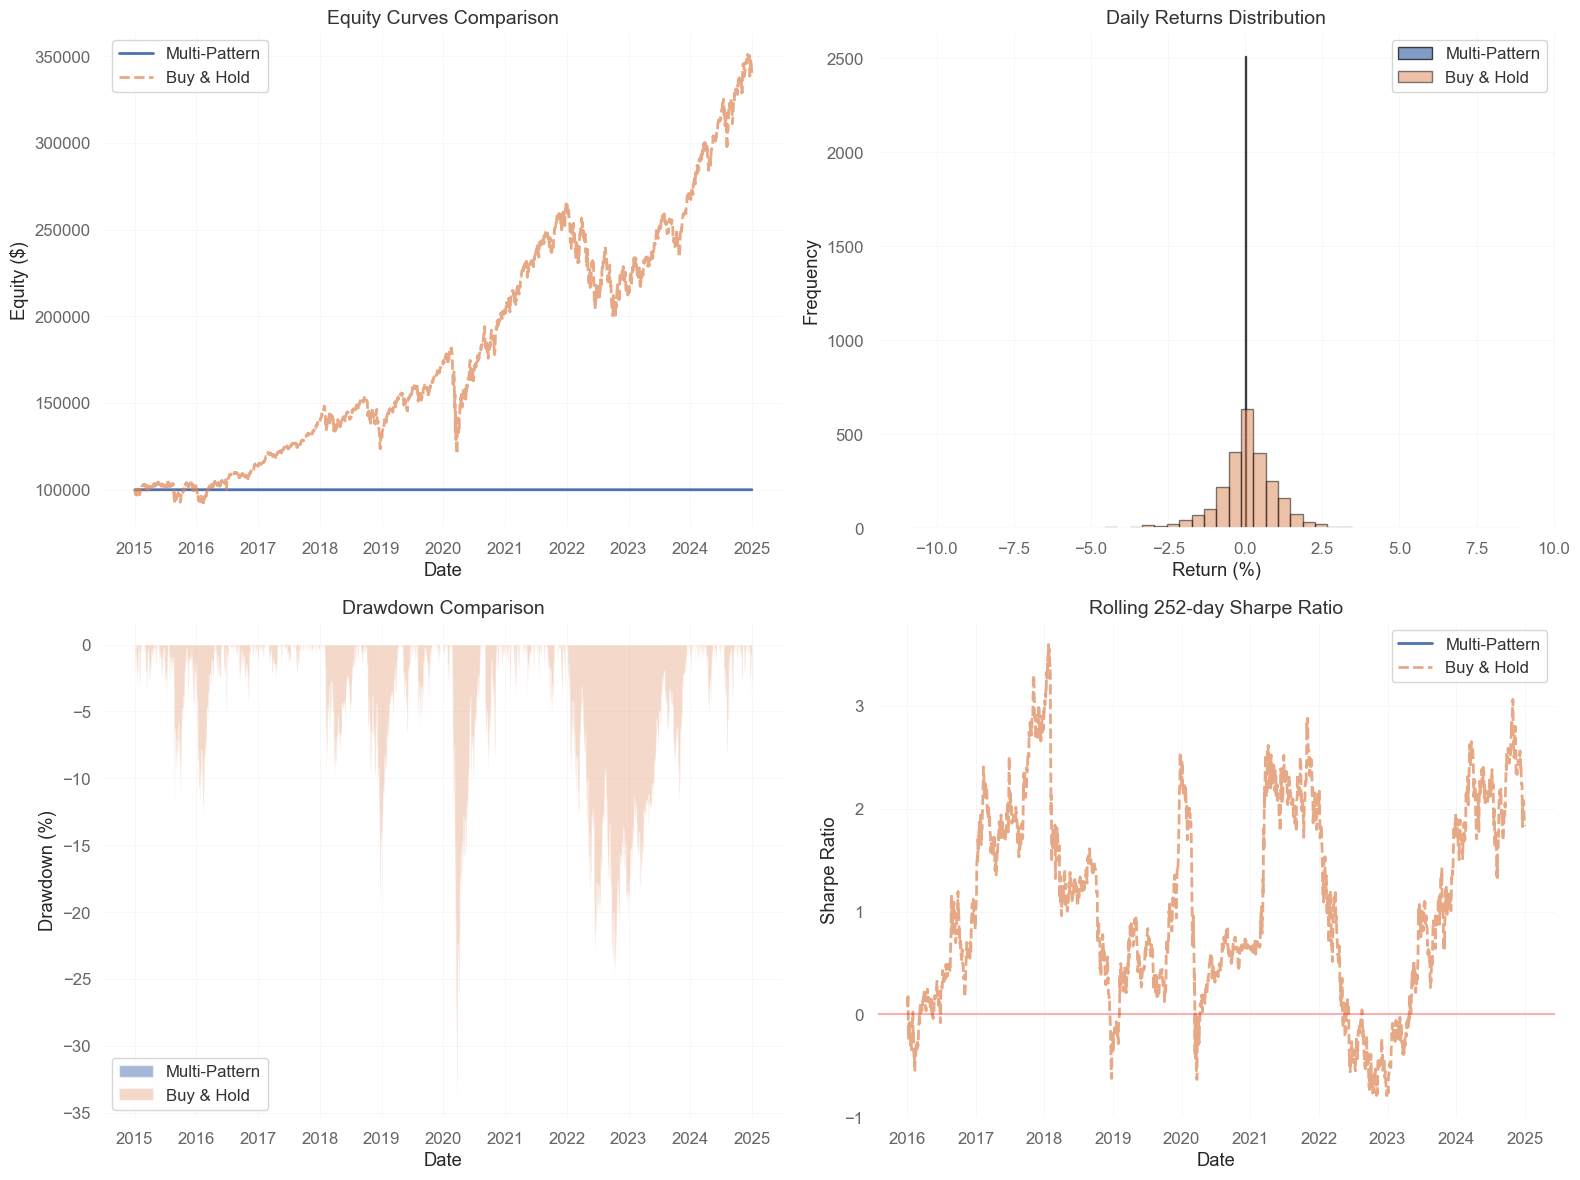

In [6]:
# Plot equity curves
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Equity curves
ax1 = axes[0, 0]
ax1.plot(mp_equity.index, mp_equity.values, label='Multi-Pattern', linewidth=2)
ax1.plot(bh_equity.index, bh_equity.values, label='Buy & Hold', linewidth=2, linestyle='--', alpha=0.7)
ax1.set_title('Equity Curves Comparison', fontsize=14)
ax1.set_xlabel('Date')
ax1.set_ylabel('Equity ($)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Returns distribution
ax2 = axes[0, 1]
mp_returns = mp_equity.pct_change().dropna()
bh_returns = bh_equity.pct_change().dropna()
ax2.hist(mp_returns * 100, bins=50, alpha=0.7, label='Multi-Pattern', edgecolor='black')
ax2.hist(bh_returns * 100, bins=50, alpha=0.5, label='Buy & Hold', edgecolor='black')
ax2.set_title('Daily Returns Distribution', fontsize=14)
ax2.set_xlabel('Return (%)')
ax2.set_ylabel('Frequency')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Drawdown comparison
ax3 = axes[1, 0]
mp_dd = (mp_equity - mp_equity.cummax()) / mp_equity.cummax() * 100
bh_dd = (bh_equity - bh_equity.cummax()) / bh_equity.cummax() * 100
ax3.fill_between(mp_dd.index, mp_dd, 0, alpha=0.5, label='Multi-Pattern')
ax3.fill_between(bh_dd.index, bh_dd, 0, alpha=0.3, label='Buy & Hold')
ax3.set_title('Drawdown Comparison', fontsize=14)
ax3.set_xlabel('Date')
ax3.set_ylabel('Drawdown (%)')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Rolling Sharpe Ratio
ax4 = axes[1, 1]
window = 252
mp_rolling_sharpe = (mp_returns.rolling(window).mean() / mp_returns.rolling(window).std()) * np.sqrt(252)
bh_rolling_sharpe = (bh_returns.rolling(window).mean() / bh_returns.rolling(window).std()) * np.sqrt(252)
ax4.plot(mp_rolling_sharpe.index, mp_rolling_sharpe.values, label='Multi-Pattern', linewidth=2)
ax4.plot(bh_rolling_sharpe.index, bh_rolling_sharpe.values, label='Buy & Hold', linewidth=2, linestyle='--', alpha=0.7)
ax4.axhline(y=0, color='red', linestyle='-', alpha=0.3)
ax4.set_title(f'Rolling {window}-day Sharpe Ratio', fontsize=14)
ax4.set_xlabel('Date')
ax4.set_ylabel('Sharpe Ratio')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()

# Save if configured
if CONFIG['output']['save_plots']:
    save_path = get_output_path(CONFIG, project_root, 'strategy_comparison.png')
    fig.savefig(save_path, dpi=CONFIG['output']['dpi'], bbox_inches='tight')

if CONFIG['output']['show_plots']:
    plt.show()
else:
    plt.close()

---

## 7. Performance Metrics Comparison

In [7]:
# Calculate metrics for both strategies
mp_metrics = calculate_performance_metrics(mp_equity)
bh_metrics = calculate_performance_metrics(bh_equity)

# Create comparison dictionary
metrics_comparison = {
    'Multi-Pattern': mp_metrics,
    'Buy & Hold': bh_metrics,
}

# Print comparison
print_metrics_comparison(metrics_comparison, title="Strategy Performance Comparison")


📊 Strategy Performance Comparison
               Total Return (%)  Annual Return (%)  Volatility (%)  Sharpe Ratio  Sortino Ratio  Calmar Ratio  Max Drawdown (%)
Multi-Pattern              0.00               0.00            0.00          0.00           0.00          0.00              0.00
Buy & Hold               239.57              13.01           17.62          0.67           0.81          0.39            -33.72


In [8]:
# Create comparison DataFrame
comparison_df = pd.DataFrame(metrics_comparison).T
print("\n📊 Detailed Metrics Comparison:")
display(comparison_df.round(2))


📊 Detailed Metrics Comparison:


,Total Return (%),Annual Return (%),Volatility (%),Sharpe Ratio,Sortino Ratio,Calmar Ratio,Max Drawdown (%)
Multi-Pattern,0.00,0.00,0.00,0.00,0.00,0.00,0.00
Buy & Hold,239.57,13.01,17.62,0.67,0.81,0.39,-33.72


---

## 8. Trade Analysis

In [9]:
# Analyze trades
if len(mp_trades) > 0:
    print("\n📊 Multi-Pattern Trade Analysis:")
    print(f"  Total trades: {len(mp_trades)}")
    print(f"  Win rate: {(mp_trades['pnl'] > 0).mean() * 100:.1f}%")
    
    wins = mp_trades[mp_trades['pnl'] > 0]['pnl']
    losses = mp_trades[mp_trades['pnl'] < 0]['pnl']
    
    print(f"  Average win: ${wins.mean():.2f}" if len(wins) > 0 else "  No winning trades")
    print(f"  Average loss: ${losses.mean():.2f}" if len(losses) > 0 else "  No losing trades")
    
    if len(losses) > 0 and losses.sum() != 0:
        profit_factor = wins.sum() / abs(losses.sum())
        print(f"  Profit factor: {profit_factor:.2f}")
    
    # Trade duration
    if 'duration' in mp_trades.columns:
        print(f"  Average duration: {mp_trades['duration'].mean()}")
    
    # Direction breakdown
    if 'direction' in mp_trades.columns:
        print("\n  By Direction:")
        for direction in mp_trades['direction'].unique():
            dir_trades = mp_trades[mp_trades['direction'] == direction]
            win_rate = (dir_trades['pnl'] > 0).mean() * 100
            print(f"    {direction}: {len(dir_trades)} trades, {win_rate:.1f}% win rate")

---

## 9. Summary

In [10]:
print("\n" + "="*60)
print("📊 STRATEGY COMPARISON SUMMARY")
print("="*60)
print(f"\nDate Range: {df.index.min().date()} to {df.index.max().date()}")
print(f"Trading Days: {len(df)}")

print("\n📈 Returns:")
print(f"  Multi-Pattern: {mp_metrics['Total Return (%)']:.2f}%")
print(f"  Buy & Hold:    {bh_metrics['Total Return (%)']:.2f}%")

print("\n📊 Risk Metrics:")
print(f"  Multi-Pattern Sharpe: {mp_metrics['Sharpe Ratio']:.2f}")
print(f"  Buy & Hold Sharpe:    {bh_metrics['Sharpe Ratio']:.2f}")
print(f"  Multi-Pattern Max DD: {mp_metrics['Max Drawdown (%)']:.2f}%")
print(f"  Buy & Hold Max DD:    {bh_metrics['Max Drawdown (%)']:.2f}%")

print("\n📊 Trade Statistics:")
print(f"  Multi-Pattern trades: {len(mp_trades)}")
if len(mp_trades) > 0:
    print(f"  Multi-Pattern win rate: {(mp_trades['pnl'] > 0).mean() * 100:.1f}%")

print("\n" + "="*60)


📊 STRATEGY COMPARISON SUMMARY

Date Range: 2015-01-02 to 2024-12-31
Trading Days: 2516

📈 Returns:
  Multi-Pattern: 0.00%
  Buy & Hold:    239.57%

📊 Risk Metrics:
  Multi-Pattern Sharpe: 0.00
  Buy & Hold Sharpe:    0.67
  Multi-Pattern Max DD: 0.00%
  Buy & Hold Max DD:    -33.72%

📊 Trade Statistics:
  Multi-Pattern trades: 0

